# Train classifiers

This notebook will use the training dataset created by notebook `00c` to train the PU and SVM models.

If training data has been extracted from the source datasets by running the `00c-extract_training_data_global.ipynb` and `00b-extract_grid_data.ipynb` notebooks, set the `use_extracted_data` variable below to `True` to use this dataset instead of the pre-prepared training data from the [Zenodo repository](https://zenodo.org/record/8157691).

## Notebook setup

These cells set some of the important variables and definitions used throughout the notebook, based on the selected config file.

### Config

In [1]:
config_file = "config/.run_config.yml"

In [2]:
from lib.paths import PathConfigManager
pcm = PathConfigManager(config_file, notebook="01")

# =====================
# Filestructure
# =====================

# Base directories
plate_model_dir = pcm.PLATE_MODEL_DIR
points_data_dir = pcm.POINTS_DATA_DIR
output_dir = pcm.OUTPUT_DIR

pcm.create_directories()

# Input data filepaths
regions_filepath = pcm.REGIONS_PATH
training_data_filepath = pcm.TRAINING_DATA_PATH

# =====================
# Notebook scope
# =====================

# Gates for determining scope of notebook run (i.e. which feature sets can be selected from)
use_features = pcm.use_features

# If True, use training data extracted in notebook 00b, 00c
# Else, use pre-prepared training data downloaded from Zenodo
use_extracted_data = pcm.use_extracted_data

# If False, skip training the SVM models
create_svm = pcm.config["create_svm"]

# If False, skip training all regional models (PU and SVM)
create_regional_models = pcm.config["create_regional_models"]

# =====================
# Model training parameters
# =====================

# Timespan for plotting
min_time = pcm.config["timespan"]["min"]
max_time = pcm.config["timespan"]["max"]
times = range(min_time, max_time + 1)

# If this parameter is False, perform feature selection using all data for all models
# If True, perform feature selection for each model individually
use_same_features = pcm.config["use_same_features"]

# If this parameter is False, selected features must be specified below
# Otherwise, they will be selected automatically
automatic_feature_selection = pcm.config["automatic_feature_selection"]

# Random seed for reproducibility
random_seed = pcm.config["random_seed"]

# Number of processes to use
n_jobs = pcm.config["n_jobs"]

# Overwrite any existing output files
overwrite = pcm.config["overwrite_output"]

# Control verbosity level of logging output
verbose = pcm.config["verbose"]

### Imports

In [3]:
import warnings

import cartopy.crs as ccrs
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from cartopy.mpl.gridliner import (
    LATITUDE_FORMATTER,
    LONGITUDE_FORMATTER,
)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from pulearn.bagging import BaggingPuClassifier
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import IterativeImputer
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
)
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

from lib.check_files import check_prepared_data
from lib.misc import (
    format_feature_name,
)
from lib.pu import (
    PU_PARAMS,
    COLUMNS_TO_DROP,
    PRESERVATION_COLUMNS,
    # downsample_unlabelled,
)

# Use figure style template in config directory
plt.style.use(pcm.CONFIG_DIR / "thesis.mplstyle")

# Suppress FutureWarning for some versions of pandas
pd.set_option('future.no_silent_downcasting', True)

# Suppress FutureWarning for some versions of Scikit-learn
%env PYTHONWARNINGS=ignore

# Suppress some other warnings
warnings.simplefilter("ignore", ConvergenceWarning)

objc[81532]: Class QT_ROOT_LEVEL_POOL__THESE_OBJECTS_WILL_BE_RELEASED_WHEN_QAPP_GOES_OUT_OF_SCOPE is implemented in both /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt6Core.6.11.0.dylib (0x1ac384738) and /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt5Core.5.15.15.dylib (0x1a788b3d0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[81532]: Class KeyValueObserver is implemented in both /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt6Core.6.11.0.dylib (0x1ac384760) and /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt5Core.5.15.15.dylib (0x1a788b3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[81532]: Class RunLoopModeTracker is implemented in both /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt6Core.6.11.0.dylib (0x1ac3847b0) and /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt5Core.5.15.1

env: PYTHONWARNINGS=ignore


/var/folders/vn/gbv894gx5fncbnm4wbnf90080000gn/T/ipykernel_81532/3382293809.py:47: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.


### Input and output files

In [4]:
if use_extracted_data:
    print(f"Using extracted training data in {points_data_dir}")
else:
    print(f"Using prepared training data in {pcm.PREPARED_DATA_DIR}")
    prep_dir = check_prepared_data(pcm.PREPARED_DATA_DIR, verbose=True)
    prep_dir = Path(prep_dir)
    grid_data_filepath = prep_dir / "grid_data.csv"
    training_filepath = prep_dir / "training_data_global.csv"

output_deposits = output_dir / "deposits"
figures_dir = output_dir / "feature_selection"
figures_dir.mkdir(parents=True, exist_ok=True)

pu_dir = output_dir / "PU"
pu_dir.mkdir(parents=True, exist_ok=True)
pu_basename = pu_dir / "classifier"

importance_dir = pu_dir / "feature_importance"
importance_dir.mkdir(parents=True, exist_ok=True)
importance_basename = importance_dir / "feature_importance"

if create_svm:
    svm_dir = output_dir / "SVM"
    svm_dir.mkdir(parents=True, exist_ok=True)
    svm_basename = svm_dir / "classifier"

Using extracted training data in /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/data_extracted/zahirovic2022/polygons_points/trenches_9.0_deg_buffer


### Classifier parameters

In [5]:
# Parameters for models
imputer_params = {
    "random_state": random_seed,
    "add_indicator": False,
}
rf_params = {
    "random_state": random_seed,
    "n_estimators": 50,
    "n_jobs": 1,
}
pu_params = {
    **PU_PARAMS,
    "n_jobs": n_jobs,
    "random_state": random_seed,
    "n_estimators": 50,
    "balanced_subsample": True,
}
svm_params = {
    "kernel": "rbf",
    "probability": True,
    "random_state": random_seed,
}

Define model and preprocessing pipeline:

In [6]:
pu_model = BaggingPuClassifier(
    RandomForestClassifier(**rf_params),
    **pu_params
)
preprocessing = make_pipeline(
    IterativeImputer(**imputer_params),
    RobustScaler(),
    VarianceThreshold(),
)
pu_pipeline = Pipeline([("preprocessing", preprocessing), ("classifier", pu_model)])
pu_pipeline.set_output(transform="pandas")

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('iterativeimputer', ...), ('robustscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,estimator,None
,missing_values,nan
,sample_posterior,False


## Training data

These cells load and plot the training data.

In [11]:
data = pd.read_csv(training_data_filepath)

data.columns

Index(['present_lon', 'present_lat', 'age (Ma)', 'Cu (Mt)', 'source', 'label',
       'plate_id', 'lon', 'lat', 'overriding_plate_id',
       ...
       'mantle_relative_east_velocity_lab+160km (cm/yr)',
       'mantle_relative_north_velocity_lab+160km (cm/yr)',
       'mantle_relative_speed_lab+160km (cm/yr)',
       'relative_velocity_parallel_to_plate_lab+160km (cm/yr)',
       'relative_velocity_transverse_to_plate_lab+160km (cm/yr)',
       'lab_depth_delta (km/timestep)',
       '1000k_isotherm_depth_delta (km/timestep)',
       'sublithospheric_cold_anomaly_thickness_delta (km/timestep)',
       'cold_anomaly_magnitude_delta (K/timestep)', 'region'],
      dtype='str', length=138)

### Columns to drop

In [12]:
# Drop individual water/carbon components, only use totals
component_columns = {
    "base_lithosphere_water_thickness (m)",
    "sedimentary_bound_water_thickness (m)",
    "sedimentary_pore_water_thickness (m)",
    "mantle_lithosphere_water_thickness (m)",
    "crustal_pore_water_thickness (m)",
    "crustal_bound_water_thickness (m)",
    "subducted_carbonate_volume (m)",
    "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "crustal_carbon_density (t/m^2)",
}
# Use orthogonal/parallel velocity vector components
component_columns |= {
    "subducting_plate_absolute_velocity (cm/yr)",
    "convergence_rate (cm/yr)",
    "trench_velocity (cm/yr)",
}
# Drop oceanic crust thickness and convergence rate,
# only use slab flux (product of the two components)
component_columns |= {
    "convergence_rate_orthogonal (cm/yr)",
    # "seafloor_age (Ma)",
    "plate_thickness (m)",
}
# Drop orthogonal components of velocity to prevent spatial leakage;
# use only overall magnitude
component_columns |= {
    component for component in data.columns if "east" in component or "north" in component
}

### Load training data

In [13]:
data = pd.read_csv(training_data_filepath)

# Remove duplicate points
# Duplicates arise from a one-to-many overriding-plate
# spatial join in combine_point_data() (notebook 00b).
# Deduplication prevents model bias from over-representation of certain locations.
data = data.drop_duplicates(subset=["lon", "lat", "age (Ma)"], keep="first")

# Skip regions with < 50 deposits
regions_to_skip = set()
for region, subset in data.groupby("region"):
    if (subset["label"] == "positive").sum() < 50:
        regions_to_skip.add(region)
data = data[~data["region"].isin(regions_to_skip)]

# # Equal number of positive and unlabelled samples      <--- ????????
# negatives = data[data["label"] == "negative"]
# tmp = data[data["label"] != "negative"]
# tmp_downsampled = downsample_unlabelled(
#     tmp,
#     random_state=random_seed,
# )
# data = pd.concat((tmp_downsampled, negatives))
df_subset = cleaned = data.drop(
    columns=list(COLUMNS_TO_DROP | PRESERVATION_COLUMNS | component_columns),
    errors="ignore",
)
# del tmp, tmp_downsampled

print("Training data summary:")
print(data.groupby(["region", "label"]).size())
print("\nOverall class distribution:")
print(data.groupby(["label"]).size())

Training data summary:
region          label     
East Asia       negative         8
                positive       213
                unlabelled    6939
North America   negative        58
                positive       441
                unlabelled    7016
South America   negative       642
                positive       175
                unlabelled    7291
Southeast Asia  negative        13
                positive       143
                unlabelled    4480
Tethys          negative        12
                positive       466
                unlabelled    5199
dtype: int64

Overall class distribution:
label
negative        733
positive       1438
unlabelled    30925
dtype: int64


## Global PU model validation

### Wrangle training data

In [ ]:
# Wrangle the training data to the required format
train_pu = cleaned[cleaned["label"].isin({"positive", "unlabelled"})]
x_pu = train_pu.drop(columns="label")
y_pu = train_pu["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

# Load the features selected in notebook 01a
selected_features = pd.read_csv(output_dir / "selected_features.csv")["selected_features"].tolist()
X_pu = x_pu[selected_features]

In [ ]:
def plot_auc_pr_curve(precision, recall, pr_auc, region_label):
    plt.figure(figsize=(6, 6))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curves for {region_label}")
    plt.legend()
    plt.grid()
    plt.tight_layout()

### Train model

The model will be written to a `.joblib` file in the output directory.

In [ ]:
pu_pipeline.fit(X_pu, y_pu)
_ = joblib.dump(pu_pipeline, pu_basename.with_suffix(".joblib"), compress=True)

### AUC-PR for full model

In [34]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

pu_pipeline.fit(X_pu, y_pu)
# Evaluate on training set to test recall. Not a measure of generalisation performance, but at least checks that the model can learn something from the data.
y_scores = pu_pipeline.predict_proba(X_pu)[:, 1]
precision, recall, _ = precision_recall_curve(y_pu, y_scores)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(y_pu, y_scores)
# Plot precision-recall curves
print(f"PR AUC = {pr_auc:.3f}, Average Precision = {avg_precision:.3f}")

PR AUC = 0.998, Average Precision = 0.998


### Regional cross-validation

In [ ]:
regions = data[data["label"].isin({"positive", "unlabelled"})]["region"]
region_groups, labels = pd.factorize(regions)

for group, label in zip(np.unique(region_groups), labels):
    print(f"Group {group}: {label}")

Group 0: Tethys
Group 1: Southeast Asia
Group 2: East Asia
Group 3: North America
Group 4: South America


Fold Tethys: PR AUC = 0.130, Average Precision = 0.131


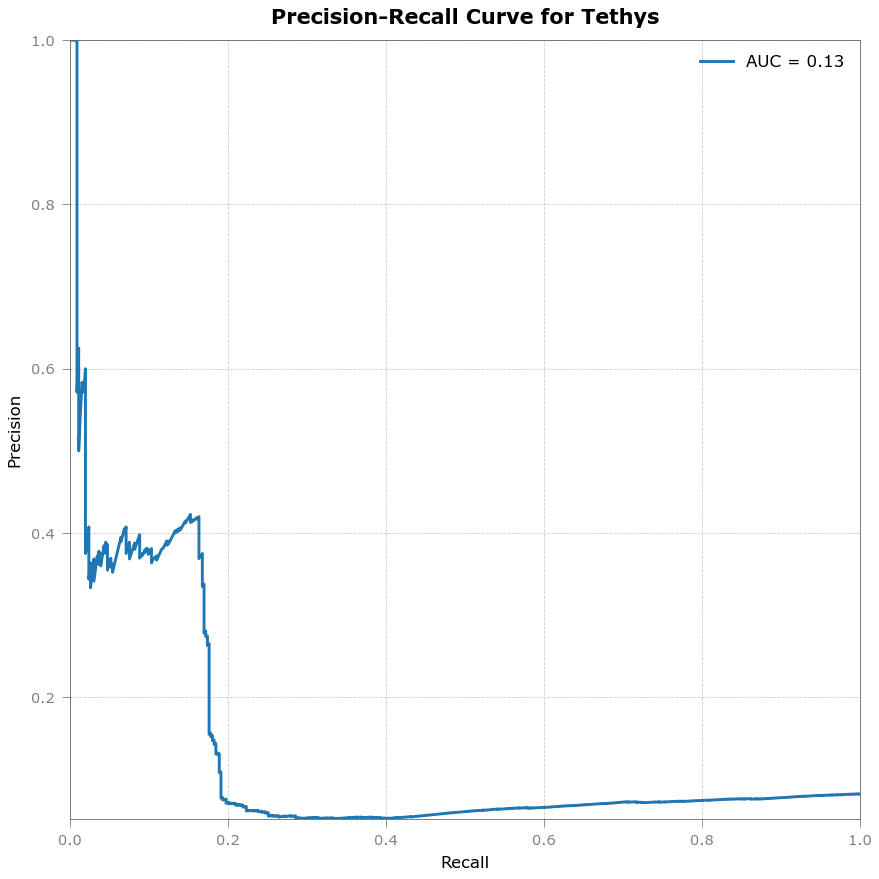

Fold Southeast Asia: PR AUC = 0.034, Average Precision = 0.035


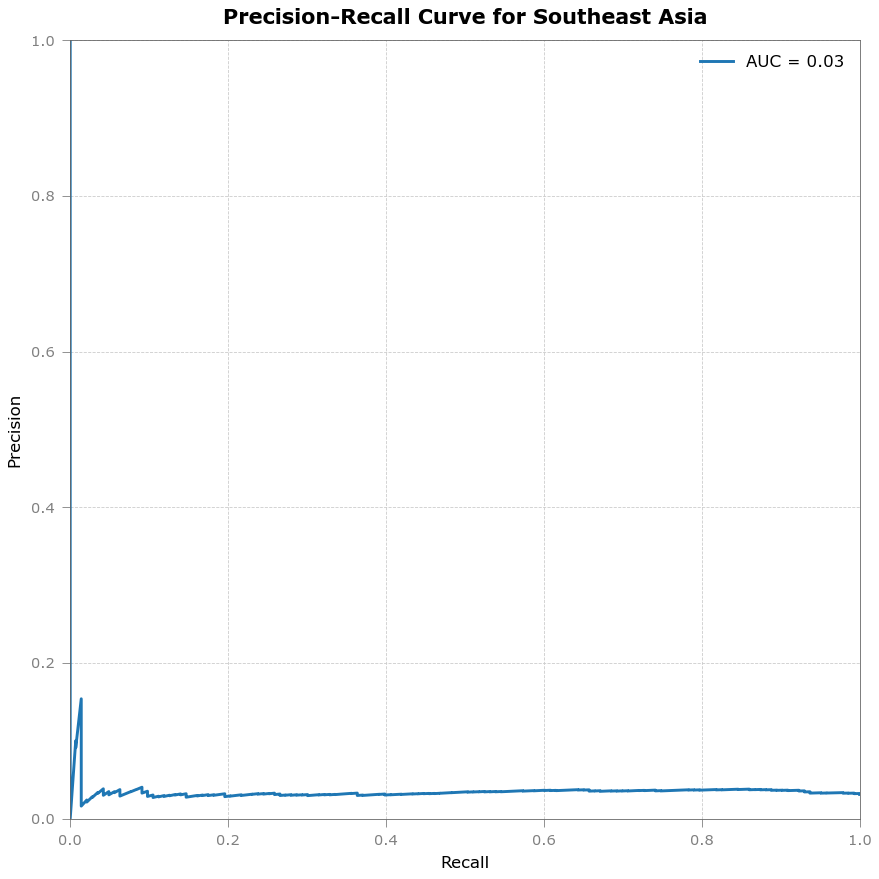

Fold East Asia: PR AUC = 0.044, Average Precision = 0.045


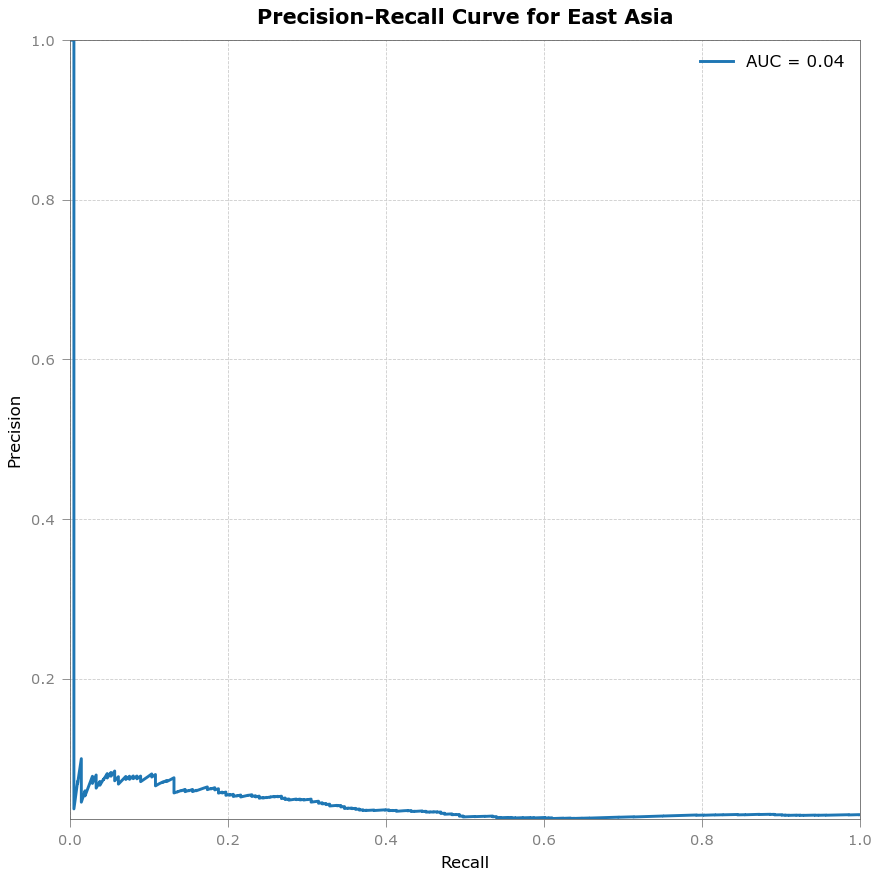

Fold North America: PR AUC = 0.063, Average Precision = 0.064


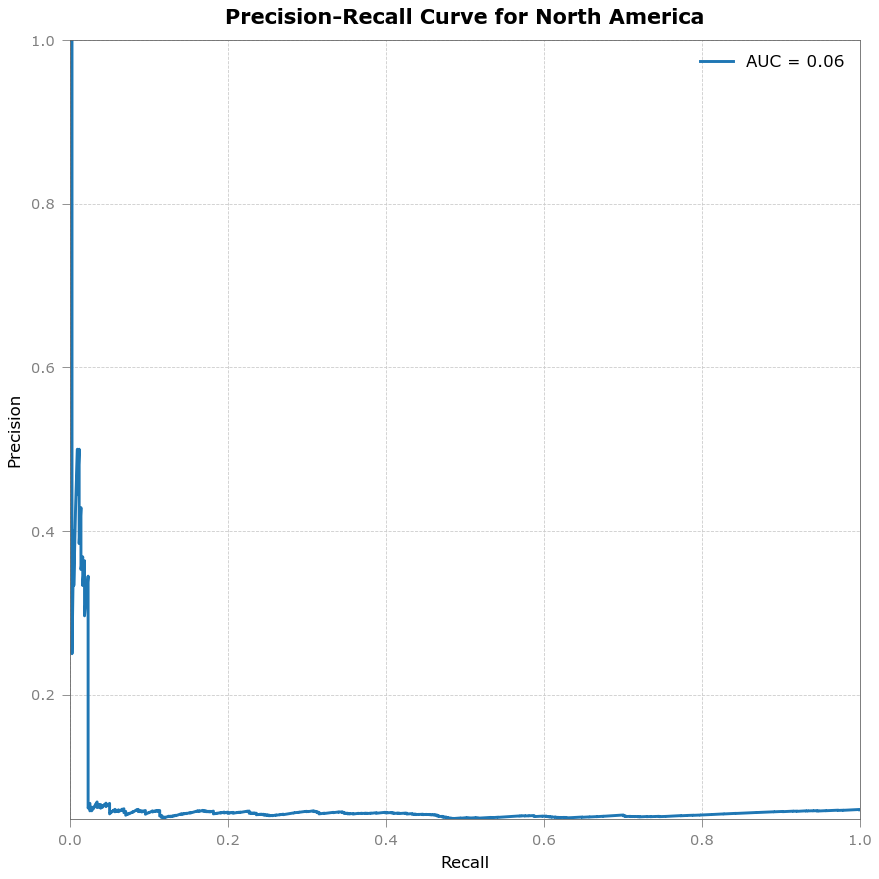

Fold South America: PR AUC = 0.021, Average Precision = 0.021


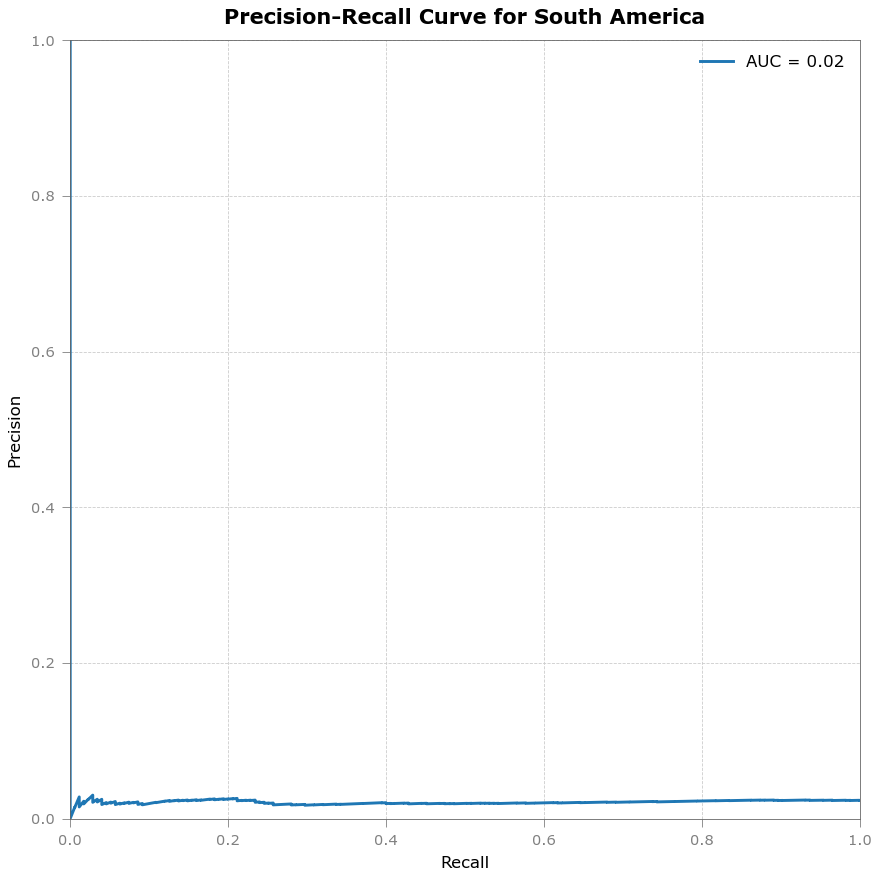

In [37]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
# LeaveOneGroupOut cross-validation for PU model
regions = data[data["label"].isin({"positive", "unlabelled"})]["region"]
region_groups, group_labels = pd.factorize(regions)

logo = LeaveOneGroupOut()
for train_index, test_index in logo.split(X_pu, groups=region_groups):
    X_train, X_test = X_pu.iloc[train_index], X_pu.iloc[test_index]
    y_train, y_test = y_pu.iloc[train_index], y_pu.iloc[test_index]
    pu_pipeline.fit(X_train, y_train)
    # Evaluate on test set and store results (e.g. predictions, feature importance)
    y_scores = pu_pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)
    avg_precision = average_precision_score(y_test, y_scores)
    # Plot precision-recall curves
    print(f"Fold {regions.iloc[test_index].iloc[0]}: PR AUC = {pr_auc:.3f}, Average Precision = {avg_precision:.3f}")

    plot_auc_pr_curve(precision, recall, pr_auc, region_label=regions.iloc[test_index].iloc[0])


### Spatially-stratified cross-validation

In [ ]:
# assign spatial folds by gridding the data into 10°x10°x10Myr cells and assigning each cell to a fold


## Train regional models

#### Plots

Region: East Asia
label
positive       142
unlabelled    6924
dtype: int64
Region: North America
label
positive       283
unlabelled    7106
dtype: int64
Region: South America
label
positive       160
unlabelled    6790
dtype: int64
Region: Southeast Asia
label
positive       123
unlabelled    4420
dtype: int64
Region: Tethys
label
positive       281
unlabelled    5587
dtype: int64


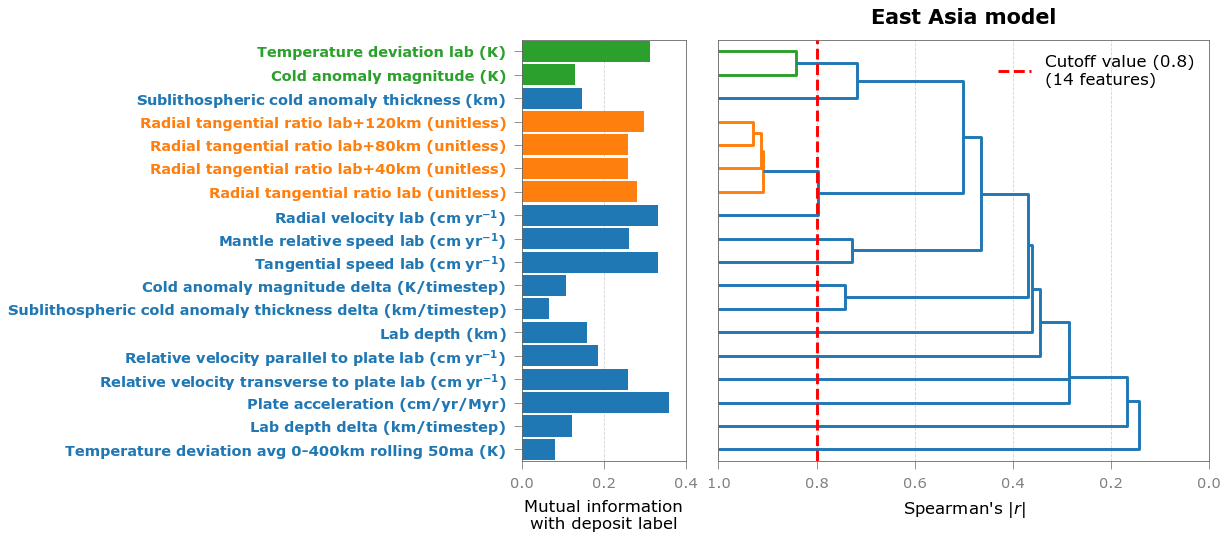

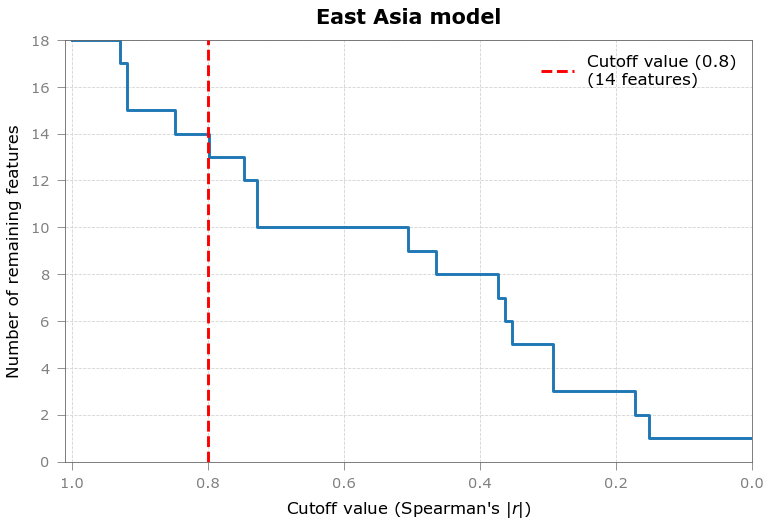

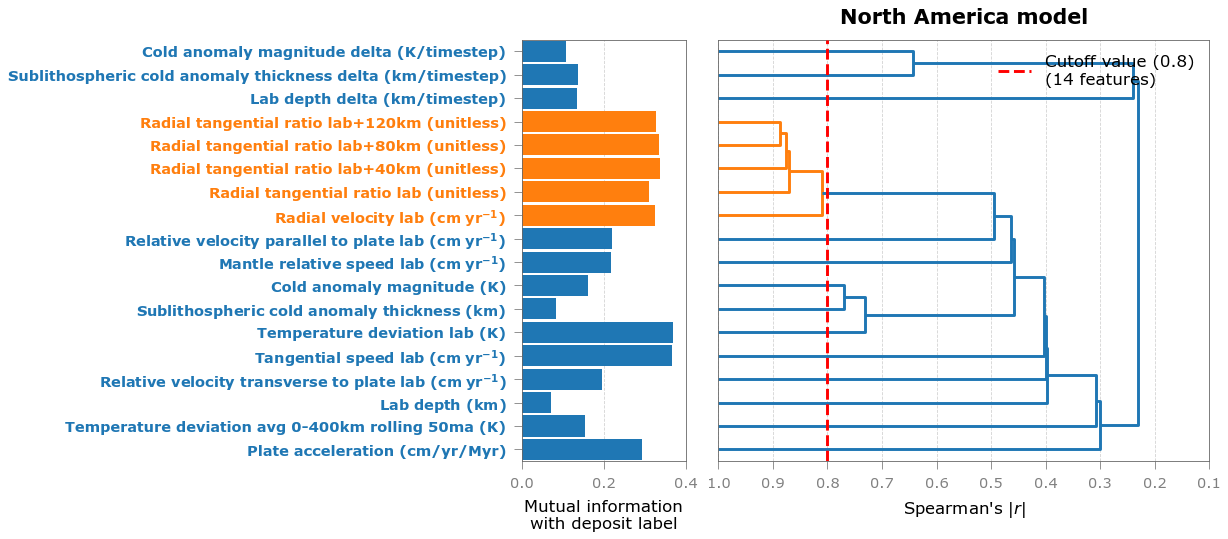

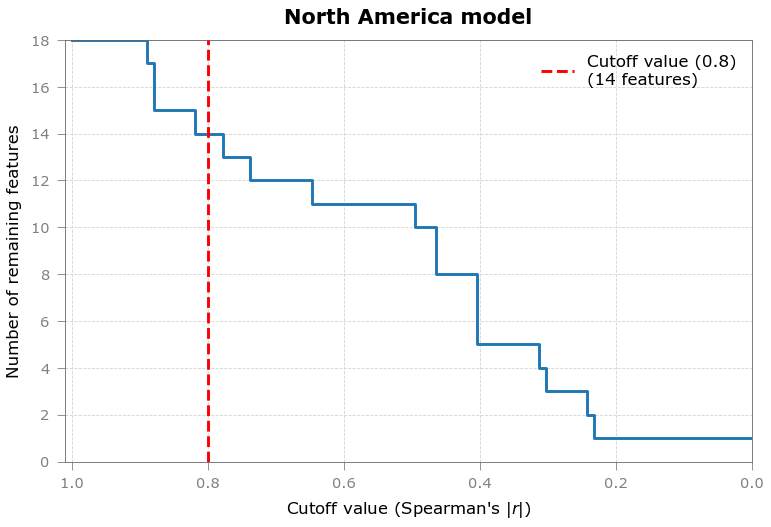

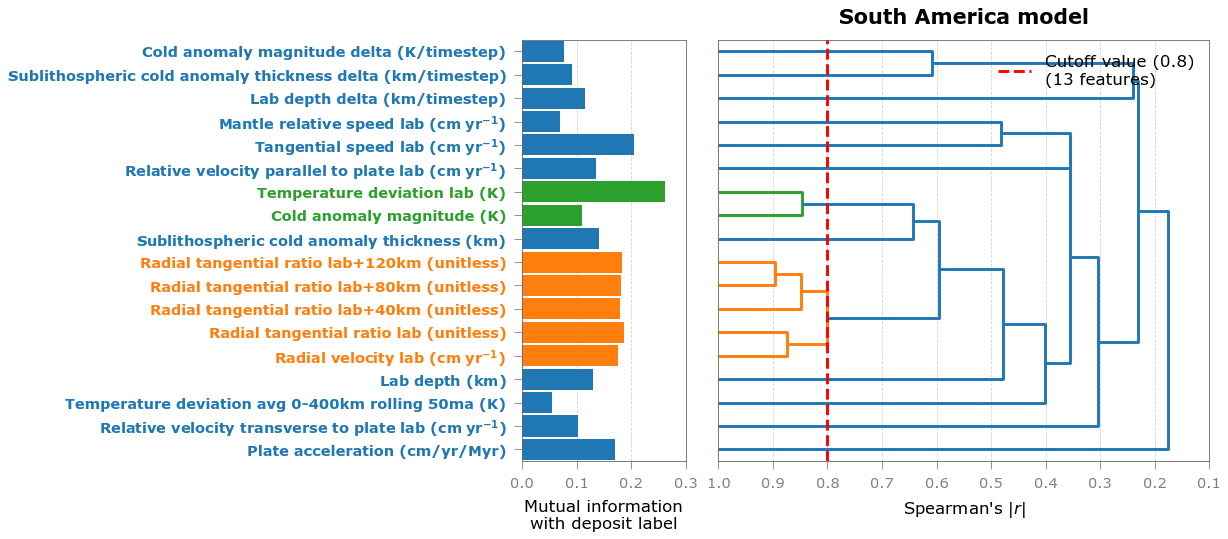

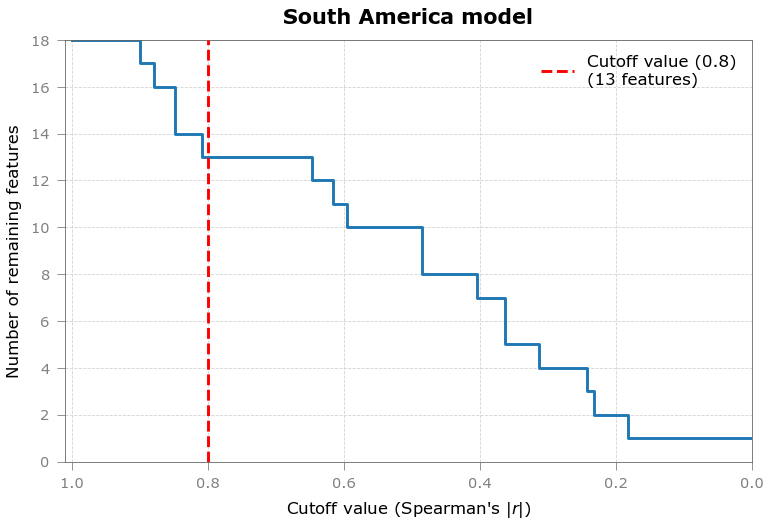

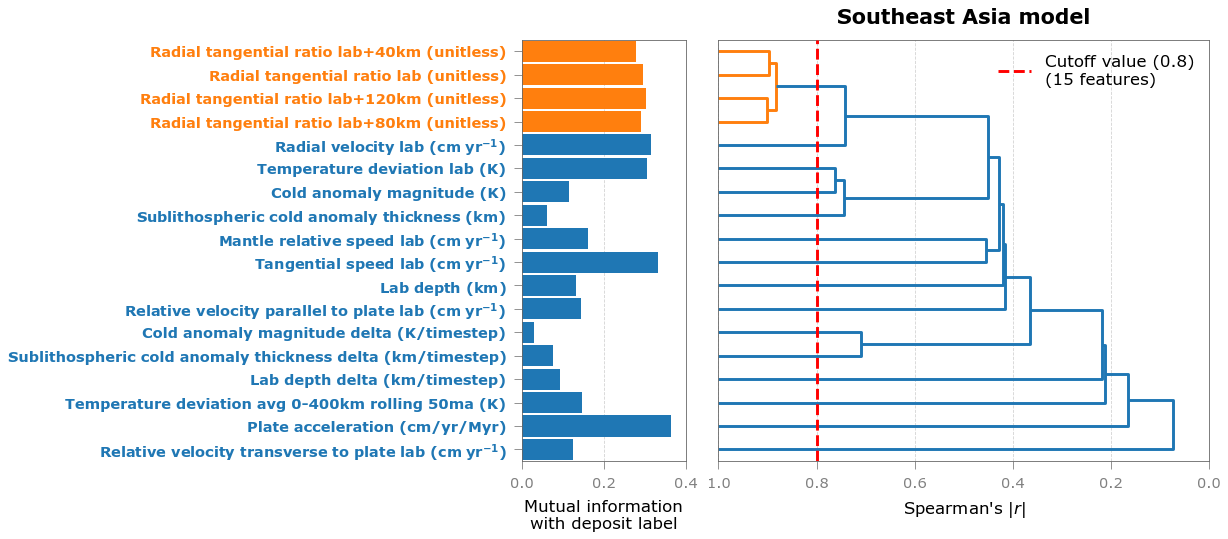

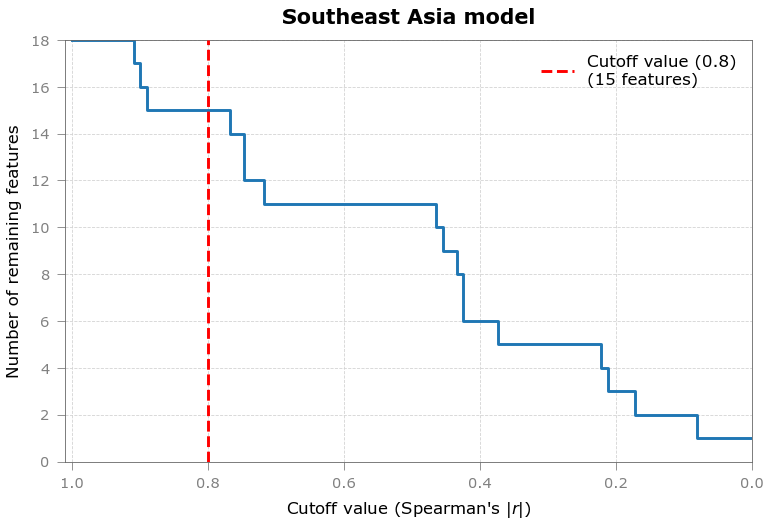

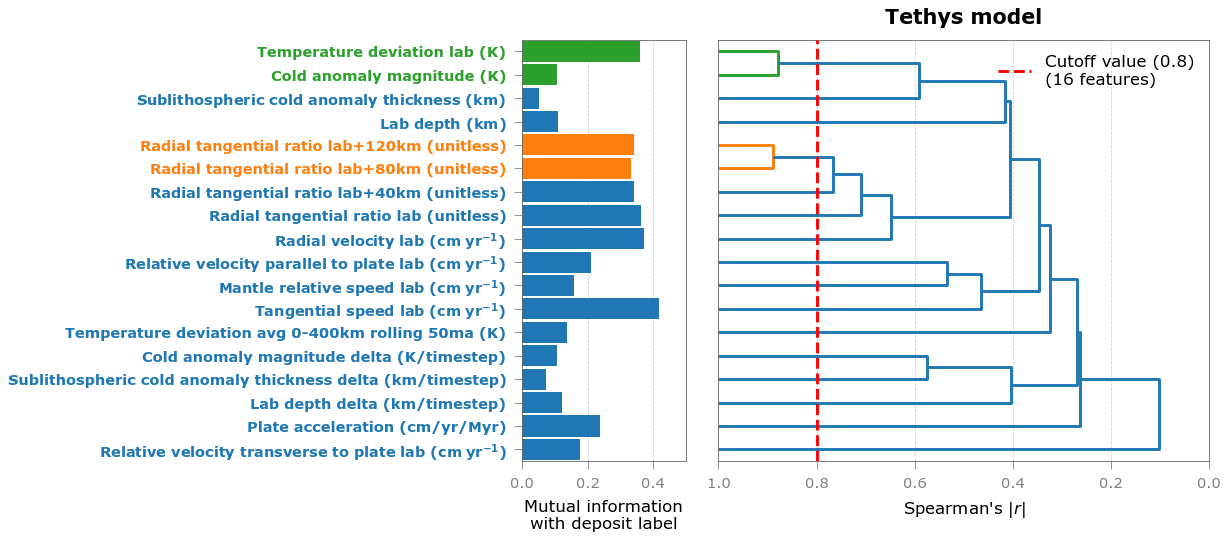

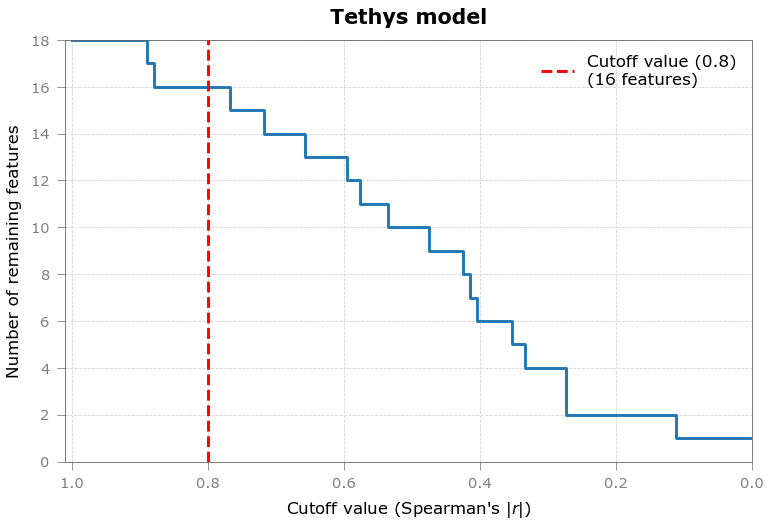

In [92]:
clusters_regions = {}
mi_series_regions = {}
if create_regional_models:
    for region, subset in data.groupby("region"):
        region = str(region)
        if (subset["label"] == "positive").sum() < 50:
            print(f"Skipping region: {region}")
            continue
        subset = subset.drop(
            columns=list(COLUMNS_TO_DROP | PRESERVATION_COLUMNS | component_columns),
            errors="ignore",
        )
        r = "_".join(region.lower().split())

        print(f"Region: {region}")
        subset = subset[subset["label"].isin({"positive", "unlabelled"})]
        print(subset.groupby("label").size())
        x_pu_subset = subset.drop(columns="label")
        y_pu_subset = subset["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")
        preprocessing_subset = clone(preprocessing).fit(x_pu_subset)
        fnames_subset = preprocessing_subset.get_feature_names_out()
        X_preprocessed_subset = preprocessing_subset.transform(x_pu_subset)

        Z_subset = linkage(
            X_preprocessed_subset.T,
            method="single",
            metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
        )

        cluster_ids_subset = fcluster(Z_subset, cluster_threshold, criterion="distance")
        clusters_subset = {
            cluster_id: list(fnames_subset[cluster_ids_subset == cluster_id])
            for cluster_id in np.unique(cluster_ids_subset)
        }
        clusters_regions[region] = clusters_subset

        mi_scores_subset = mutual_info_classif(
            X_preprocessed_subset,
            y_pu_subset,
            random_state=random_seed,
        )
        p_subset = y_pu_subset.mean()
        mi_normalised_subset = mi_scores_subset / scipy_entropy([p_subset, 1 - p_subset])
        mi_series_regions[region] = pd.Series(mi_normalised_subset, index=fnames_subset)

        # Plot dendrogram + MI bars for this region
        mi_dendrogram_filename_subset = figures_dir / f"mi_dendrogram_{r}"
        fig_dims = (5.91, max(3.65, len(x_pu_subset.columns) * 0.17))
        fig, (ax_mi, ax_dendro) = plt.subplots(
            1, 2, figsize=fig_dims, sharey=True,
            gridspec_kw={"width_ratios": [1, 3], "wspace": 0.1},
        )
        dendro = dendrogram(
            Z_subset,
            orientation="right",
            labels=[format_feature_name(i, bold=True) for i in fnames_subset],
            ax=ax_dendro,
            color_threshold=cluster_threshold,
        )
        ax_dendro.axvline(cluster_threshold, linestyle="dashed", color="red", zorder=10,
            label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters_subset)} features)")
        ax_dendro.grid(linestyle="dashed", color="lightgrey", axis="x")
        ax_dendro.set_xticks(ax_dendro.get_xticks(), [f"{1 - i:0.1f}" for i in ax_dendro.get_xticks()])
        ax_dendro.set_xlabel(r"Spearman's $|r|$")
        ax_dendro.tick_params(labelleft=False, left=False)
        ax_dendro.legend(loc="best")
        ax_dendro.set_title(f"{region} model")

        leaf_colours = dendro["leaves_color_list"]
        ordered_features = [fnames_subset[i] for i in dendro["leaves"]]
        ordered_mi = [mi_series_regions[region][f] for f in ordered_features]

        y_pos = np.arange(len(ordered_features)) * 10 + 5
        ax_mi.barh(y_pos, ordered_mi, height=9, color=leaf_colours, edgecolor="none")
        ax_mi.set_xlim(0, np.ceil(max(ordered_mi) * 10) / 10)
        ax_mi.set_xlabel("Mutual information\nwith deposit label")
        ax_mi.grid(linestyle="dashed", color="lightgrey", axis="x")
        ax_mi.set_axisbelow(True)
        for label, color in zip(ax_mi.get_ymajorticklabels(), leaf_colours):
            label.set_color(color)
            label.set_fontweight("bold")
            label.set_fontsize(7)

        for ext in (".pdf", ".png"):
            fig.savefig(f"{mi_dendrogram_filename_subset}{ext}", dpi=350, bbox_inches="tight")

        thresh_clusters_subset = np.array([
            len(np.unique(fcluster(Z_subset, 1 - t, criterion="distance")))
            for t in thresh_vals
        ])

        # Cutoff vs. number of features
        cutoff_nfeatures_filename_subset = figures_dir / f"cutoff_nfeatures_{r}"
        fig, ax = plt.subplots()
        ax.step(thresh_vals, thresh_clusters_subset, where="post")
        ax.axvline(
            cutoff_value,
            linestyle="dashed",
            color="red",
            zorder=10,
            label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters_subset)} features)",
        )
        ax.set_xlim(thresh_vals.max() * 1.01, thresh_vals.min())
        ax.set_ylim(0, None)
        ax.grid(linestyle="dashed", color="lightgrey")
        ax.legend(loc="best")
        ax.set_xlabel(r"Cutoff value (Spearman's $|r|$)")
        ax.set_ylabel("Number of remaining features")
        ax.set_title(f"{region} model")

        for ext in (".pdf", ".png"):
            fig.savefig(f"{cutoff_nfeatures_filename_subset}{ext}", dpi=350, bbox_inches="tight")

In [93]:
if create_regional_models:
    for region, clusters_subset in clusters_regions.items():
        print(f"{region}:")
        for cluster_id in sorted(clusters_subset.keys()):
            print(f"  Cluster #{cluster_id}:")
            for f in clusters_subset[cluster_id]:
                print(f"    - {f}")

East Asia:
  Cluster #1:
    - sublithospheric_cold_anomaly_thickness_delta (km/timestep)
  Cluster #2:
    - cold_anomaly_magnitude_delta (K/timestep)
  Cluster #3:
    - tangential_speed_lab (cm/yr)
  Cluster #4:
    - mantle_relative_speed_lab (cm/yr)
  Cluster #5:
    - radial_tangential_ratio_lab (unitless)
    - radial_tangential_ratio_lab+40km (unitless)
    - radial_tangential_ratio_lab+80km (unitless)
    - radial_tangential_ratio_lab+120km (unitless)
  Cluster #6:
    - radial_velocity_lab (cm/yr)
  Cluster #7:
    - cold_anomaly_magnitude (K)
    - temperature_deviation_lab (K)
  Cluster #8:
    - sublithospheric_cold_anomaly_thickness (km)
  Cluster #9:
    - lab_depth (km)
  Cluster #10:
    - relative_velocity_parallel_to_plate_lab (cm/yr)
  Cluster #11:
    - relative_velocity_transverse_to_plate_lab (cm/yr)
  Cluster #12:
    - plate_acceleration (cm/yr/Myr)
  Cluster #13:
    - lab_depth_delta (km/timestep)
  Cluster #14:
    - temperature_deviation_avg_0-400km_rolling

#### Feature selection

In [94]:
# if create_regional_models:
if True:
    if use_same_features:
        print("Using same features for all models")
        selected_features_regions = {
            region: selected_features
            for region in clusters_regions.keys()
        }
    elif automatic_feature_selection:
        selected_features_regions = {
            region: [
                max(clusters_regions[region][i], key=lambda f: mi_series_regions[region].get(f, 0.0))
                for i in sorted(clusters_regions[region].keys())
            ]
            for region in clusters_regions.keys()
        }
    else:
        selected_features_regions = {
            "North America": [
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "convergence_rate_parallel (cm/yr)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "crustal_thickness_mean (m)",
                "crustal_thickness_min (m)",
                "trench_velocity_orthogonal (cm/yr)",
                "subducted_sediment_volume (m)",
                "slab_dip (degrees)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "total_water_thickness (m)",
                "sediment_thickness (m)",
                "seafloor_spreading_rate (km/Myr)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench_edge (km)",
            ],
            "South America": [
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_orthogonal (cm/yr)",
                "sediment_thickness (m)",
                "convergence_rate_parallel (cm/yr)",
                "slab_dip (degrees)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "trench_velocity_parallel (cm/yr)",
                "crustal_thickness_mean (m)",
                "distance_to_trench_edge (km)",
                "seafloor_spreading_rate (km/Myr)",
                "crustal_thickness_min (m)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
            ],
            "Southeast Asia": [
                "sediment_thickness (m)",
                "seafloor_spreading_rate (km/Myr)",
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "convergence_rate_parallel (cm/yr)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "slab_dip (degrees)",
                "crustal_thickness_mean (m)",
                "crustal_thickness_median (m)",
                "crustal_thickness_min (m)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "trench_velocity_orthogonal (cm/yr)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench_edge (km)",
            ],
            "Tethys": [
                "convergence_rate_parallel (cm/yr)",
                "convergence_obliquity (degrees)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "subducting_plate_absolute_obliquity (degrees)",
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "distance_to_trench_edge (km)",
                "crustal_thickness_mean (m)",
                "slab_dip (degrees)",
                "sediment_thickness (m)",
                "crustal_thickness_min (m)",
                "seafloor_spreading_rate (km/Myr)",
                "trench_velocity_orthogonal (cm/yr)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench (km)",
            ]
        }

Using same features for all models


#### Train regional models

In [95]:
if create_regional_models:
    for region, clusters_subset in clusters_regions.items():
        r = "_".join(region.lower().split())
        subset = data[data["region"] == region]
        subset = subset[subset["label"].isin({"positive", "unlabelled"})]
        x_pu_subset = subset.drop(columns="label")
        y_pu_subset = subset["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

        selected_features_subset = selected_features_regions[region]
        pu_pipeline_subset = clone(pu_pipeline)
        pu_pipeline_subset.set_output(transform="pandas")
        pu_pipeline_subset.fit(x_pu_subset[selected_features_subset], y_pu_subset)
        print(f" - Writing model to file: {pu_basename}_{r}.joblib")
        joblib.dump(
            pu_pipeline_subset,
            f"{pu_basename}_{r}.joblib",
            compress=True,
        )

 - Writing model to file: /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/output/mantle_test/PU/classifier_east_asia.joblib
 - Writing model to file: /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/output/mantle_test/PU/classifier_north_america.joblib
 - Writing model to file: /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/output/mantle_test/PU/classifier_south_america.joblib
 - Writing model to file: /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/output/mantle_test/PU/classifier_southeast_asia.joblib
 - Writing model to file: /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/output/mantle_test/PU/classifier_tethys.joblib


## Feature importance

Here we plot impurity (Gini) feature importance values for each of the PU models.

In [99]:
# Cross-validation iterator
n_splits = 5
n_repeats = 10
cv = RepeatedStratifiedKFold(
    n_splits=n_splits,
    n_repeats=n_repeats,
    random_state=random_seed,
)

# Plot parameters
label_size = 16
tick_size = 12
title_size = 18

### Global model

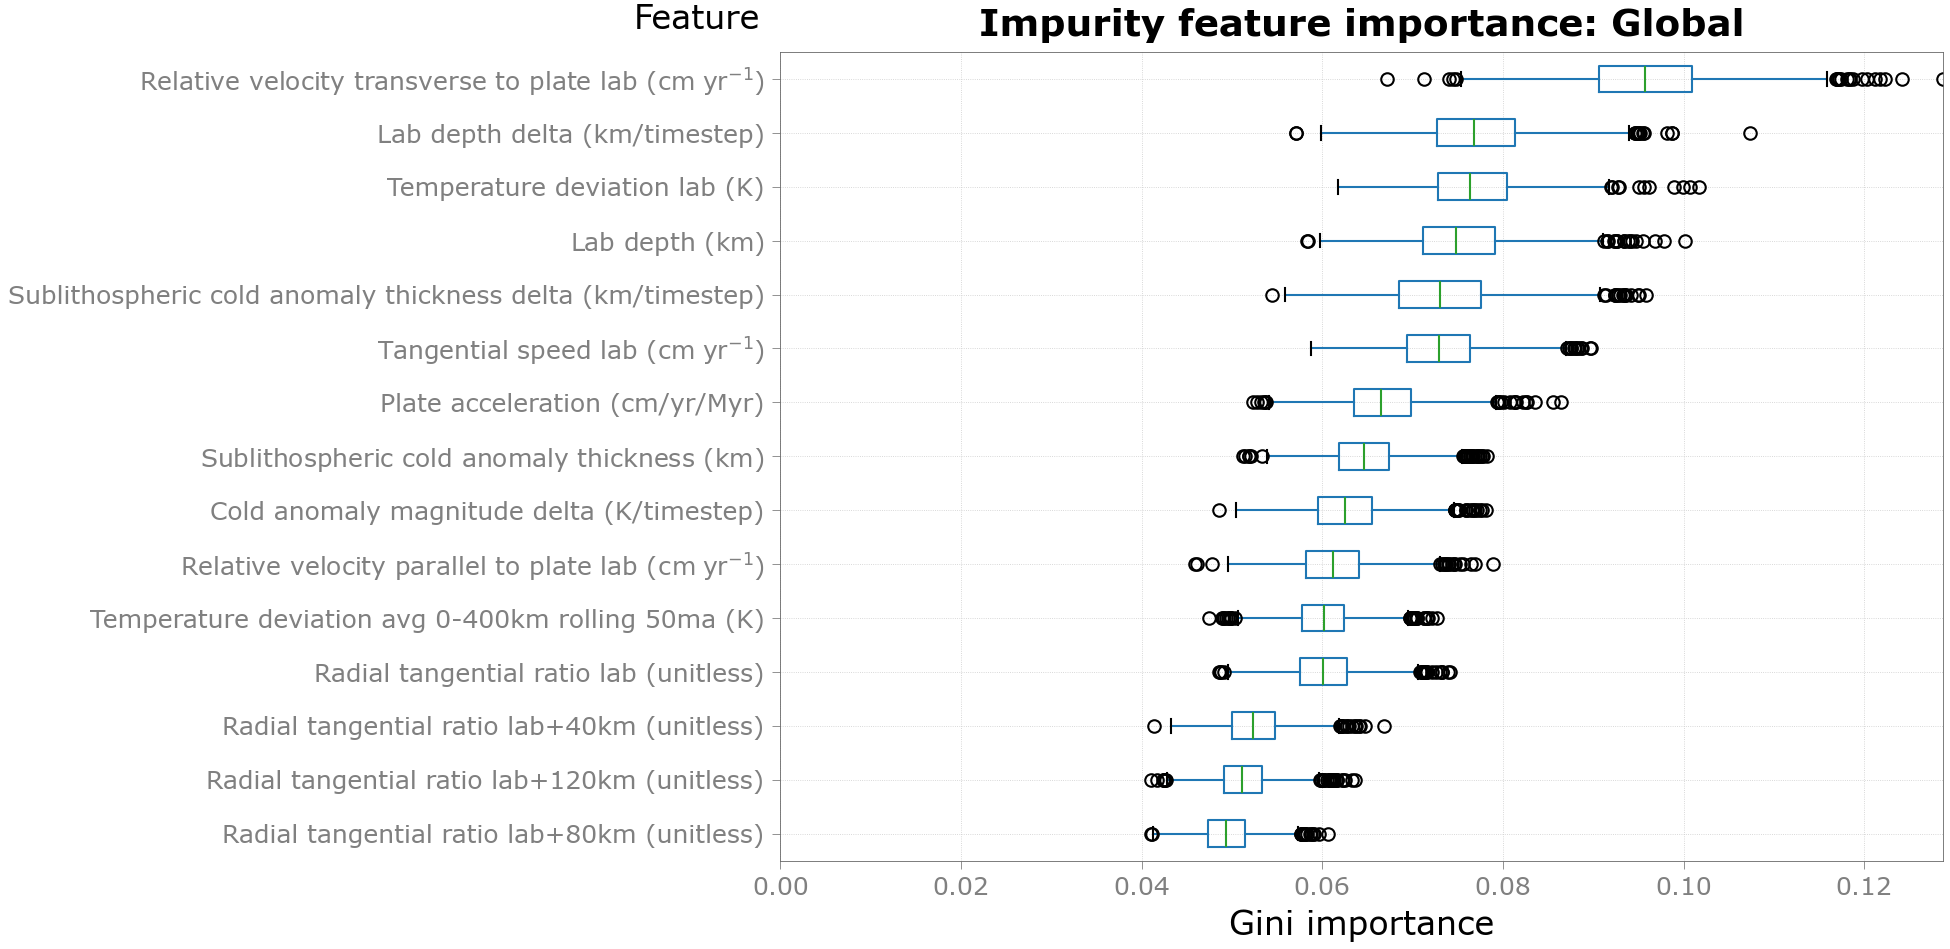

In [100]:
# Extract importances (use cross-validation for extra robustness)
model = joblib.load(pu_basename.with_suffix(".joblib"))
feature_names = model.feature_names_in_
replace = {"positive": 1, "negative": 0, "unlabelled": 0}
importances = []
for train_idx, _ in cv.split(cleaned, cleaned["label"]):
    data_train = cleaned.iloc[train_idx, :]
    data_train = data_train[data_train["label"] != "negative"]
    X_train = data_train[feature_names]
    y_train = data_train["label"].replace(replace).infer_objects()

    clf = clone(model)
    clf.fit(X_train, y_train)
    df_results = pd.DataFrame(
        np.vstack(
            [
                i.feature_importances_
                for i in clf["classifier"].estimators_
            ]
        ),
        columns=clf["preprocessing"].get_feature_names_out(),
    )
    importances.append(df_results)
importances = pd.concat(importances, ignore_index=True)
importances = importances[
    importances.median().sort_values(ascending=False).index
]
importances.to_csv(importance_basename.with_suffix(".csv"), index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)
ax.grid(linestyle="dotted")
ax.set_xlim(0)
ax.set_xlabel(
    "Gini importance",
    fontsize=label_size,
)
ax.set_ylabel(
    "Feature",
    rotation=0,
    ha="right",
    fontsize=label_size,
)
ax.yaxis.set_label_coords(x=-0.017, y=1.02)
ax.set_title(
    "Impurity feature importance: Global",
    fontsize=title_size,
)
ax.set_yticks(
    ax.get_yticks(),
    [
        format_feature_name(i.get_text())
        for i in ax.get_yticklabels()
    ]
)
ax.tick_params(labelsize=tick_size)
for ext in (".pdf", ".png"):
    fig.savefig(
        importance_basename.with_suffix(ext),
        dpi=350,
        bbox_inches="tight",
    )

### Regional models

In [ ]:
for region, clusters_subset in clusters_regions.items():
    r = "_".join(region.lower().split())
    subset = data[data["region"] == region]
    subset = subset[subset["label"].isin({"positive", "unlabelled"})]

    # Extract feature importance
    r = "_".join(region.lower().split())
    model = joblib.load(f"{pu_basename}_{r}.joblib")
    feature_names = model.feature_names_in_
    importances = []
    for train_idx, _ in cv.split(subset, subset["label"]):
        data_train = subset.iloc[train_idx, :]
        X_train = data_train[feature_names]
        y_train = data_train["label"].replace(replace).infer_objects()

        clf = clone(model)
        clf.fit(X_train, y_train)
        df_results = pd.DataFrame(
            np.vstack(
                [
                    i.feature_importances_
                    for i in clf["classifier"].estimators_
                ]
            ),
            columns=clf["preprocessing"].get_feature_names_out(),
        )
        importances.append(df_results)
    importances = pd.concat(importances, ignore_index=True)
    importances = importances[
        importances.median().sort_values(ascending=False).index
    ]
    importances.to_csv(f"{importance_basename}_{r}" + ".csv", index=False)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)
    ax.grid(linestyle="dotted")
    ax.set_xlim(0)
    ax.set_xlabel(
        "Gini importance",
        fontsize=label_size,
    )
    ax.set_ylabel(
        "Feature",
        rotation=0,
        ha="right",
        fontsize=label_size,
    )
    ax.yaxis.set_label_coords(x=-0.017, y=1.02)
    ax.set_title(
        f"Impurity feature importance: {region}",
        fontsize=title_size,
    )
    ax.set_yticks(
        ax.get_yticks(),
        [
            format_feature_name(i.get_text())
            for i in ax.get_yticklabels()
        ]
    )
    ax.tick_params(labelsize=tick_size)
    for ext in (".pdf", ".png"):
        fig.savefig(
            f"{importance_basename}_{r}" + ext,
            dpi=350,
            bbox_inches="tight",
        )

## Extra: Train the SVM models

In the following cells, the supervised SVM models are created and trained.

N.B. These models are only created for the regions for which labelled negative data exists (i.e. North and South America).

### Global dataset

#### Train model with selected features

In [ ]:
if create_svm:
    # Wrangle training data
    train_svm = cleaned[cleaned["label"].isin({"positive", "negative"})]
    x_svm = train_svm[selected_features]
    y_svm = train_svm["label"].replace({"positive": 1, "negative": 0}).astype("int")

    svm_model = SVC(**svm_params)
    svm_pipeline = Pipeline(
        [
            ("preprocessing", clone(preprocessing)),
            ("classifier", svm_model),
        ]
    )
    svm_pipeline.set_output(transform="pandas")
    svm_pipeline.fit(x_svm, y_svm)
    joblib.dump(svm_pipeline, svm_basename + ".joblib", compress=True)
    svm_pipeline

### Regional models

In [ ]:
if create_svm and create_regional_models:
    for region, subset in data.groupby("region"):
        region = str(region)
        if (
            (subset["label"] == "positive").sum() < 25
            or (subset["label"] == "negative").sum() < 25
        ):
            print(f"Skipping region: {region}")
            continue
        r = "_".join(region.lower().split())

        selected_features_subset = selected_features_regions[region]

        print(f"Region: {region}")
        subset = subset[subset["label"].isin({"positive", "negative"})]
        print(subset.groupby("label").size())
        x_svm_subset = subset[selected_features_subset]
        y_svm_subset = subset["label"].replace({"positive": 1, "negative": 0}).astype("int")

        svm_pipeline_subset = clone(svm_pipeline)
        svm_pipeline_subset.set_output(transform="pandas")
        svm_pipeline_subset.fit(x_svm_subset, y_svm_subset)

        _ = joblib.dump(
            svm_pipeline_subset,
            svm_basename + f"_{r}.joblib",
            compress=True,
        )
        print("")